# Sistemas de Big Data
## Proyecto de manipulación de datos 
**Autores:** Nicole Díaz y Enrique Ángel


IMPORTACIÓN LIBRERÍAS:D

In [1]:
import pandas as pd
import numpy as np
import sqlalchemy as sa
import seaborn as sns
from sqlalchemy import create_engine, text
import matplotlib.pyplot as plt


df_completo = pd.read_csv("csv/ventas.csv")
df_completo

,ID,ID_Pedido,ID_Factura,Supermercado,Ciudad,Tipo_cliente,Sexo,Linea_negocio,Precio_unitario,Cantidad,Total,IVA,Fecha,Pago
0,1,56904,56904-C1,Perfumes Olorosos,Vigo,Existente,Mujer,Belleza y perfumería,431.570,42,18125.90,3806.45,1973-09-25,Tarjeta crédito
1,2,56904,56904-C2,El Cercano,Pontevedra,Existente,Mujer,Supermercado,427.754,32,13688.10,2874.50,1973-09-25,Tarjeta crédito
2,3,56904,56904-C3,El Primero,Vigo,Existente,Mujer,Supermercado,125.120,55,6881.58,1445.13,1973-09-25,Tarjeta crédito
3,4,56904,56904-C4,Perfumes Olorosos,Vigo,Existente,Mujer,Belleza y perfumería,499.885,35,17496.00,3674.16,1973-09-25,Tarjeta crédito
4,5,56904,56904-C5,El Caro,Nigrán,Existente,Mujer,Cocinas,216.976,8,1735.81,364.52,1973-09-25,Tarjeta crédito
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
303,304,30066,30066-C3,Mercería Coso,A Coruña,Existente,Hombre,Otros,974.517,20,19490.30,4092.97,1998-02-04,Efectivo
304,305,30066,30066-C4,Mercería Coso,A Coruña,Existente,Hombre,Otros,131.573,39,5131.33,1077.58,1998-02-04,Efectivo
305,306,30066,30066-C5,Perfumes Olorosos,Vigo,Existente,Hombre,Belleza y perfumería,814.359,59,48047.20,10089.90,1998-02-04,Efectivo
306,307,30066,30066-C6,El Primero,Vigo,Existente,Hombre,Supermercado,867.107,90,78039.70,16388.30,1998-02-04,Efectivo


VISUALIZACIÓN :DATAFRAME DE DIRECCIONES

In [2]:
df_direcciones = pd.read_csv("csv/DIRECCIONES.csv")
df_direcciones

,ID,ID_Pedido,dir_entrega,tipo_entrega,email
0,7,56904,"Gran vía 24 1C, Madrid",Correos,twana_ellwood@yahoo.com
1,8,84698,"Rúa Rosalía de castro 28 4B, Vigo",Domicilio,emery_aitken@mail.com
2,9,14325,"Avenida de Europa 2, Vigo",Correos,thomasina_stone@hotmail.com
3,10,68893,"c/Orense 25 2C, Madrid",Domicilio,justin_higgins@gmail.com
4,11,72994,"c/agua 25 3D, Sevilla",Punto de recogida,liliana_wilde@outlook.com
5,12,82407,"c/San Lorenzo 12, Málaga",Domicilio,bo_finnegan@hotmail.com
6,13,74285,"Avinguda de Manuel Azaña 4, Barcelona",Domicilio,mayme_driscoll@yandex.com
7,14,5364,"Avenida de Casablanca 45, Madrid",Correos,jenifer_reid@zohomail.com
8,15,80407,"Calle de Canarias 1 2B, Madrid",Punto de recogida,julie_macgregor@gmail.com
9,16,18447,"c/Esla 34, León",Domicilio,yvonne_povey@mail.com


----

### INSPECCIÓN INICIAL

In [3]:
display(df_direcciones.head())
print(df_direcciones.info())
print("Nulos:", df_direcciones.isnull().sum())
print("Duplicados:", df_direcciones.duplicated().sum())
print("==================================================")
display(df_completo.head())
print(df_completo.info())
print("Nulos:", df_completo.isnull().sum())
print("Duplicados:", df_completo.duplicated().sum())

,ID,ID_Pedido,dir_entrega,tipo_entrega,email
0,7,56904,"Gran vía 24 1C, Madrid",Correos,twana_ellwood@yahoo.com
1,8,84698,"Rúa Rosalía de castro 28 4B, Vigo",Domicilio,emery_aitken@mail.com
2,9,14325,"Avenida de Europa 2, Vigo",Correos,thomasina_stone@hotmail.com
3,10,68893,"c/Orense 25 2C, Madrid",Domicilio,justin_higgins@gmail.com
4,11,72994,"c/agua 25 3D, Sevilla",Punto de recogida,liliana_wilde@outlook.com


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ID            60 non-null     int64 
 1   ID_Pedido     60 non-null     int64 
 2   dir_entrega   60 non-null     object
 3   tipo_entrega  60 non-null     object
 4   email         58 non-null     object
dtypes: int64(2), object(3)
memory usage: 2.5+ KB
None
Nulos: ID              0
ID_Pedido       0
dir_entrega     0
tipo_entrega    0
email           2
dtype: int64
Duplicados: 0


,ID,ID_Pedido,ID_Factura,Supermercado,Ciudad,Tipo_cliente,Sexo,Linea_negocio,Precio_unitario,Cantidad,Total,IVA,Fecha,Pago
0,1,56904,56904-C1,Perfumes Olorosos,Vigo,Existente,Mujer,Belleza y perfumería,431.570,42,18125.90,3806.45,1973-09-25,Tarjeta crédito
1,2,56904,56904-C2,El Cercano,Pontevedra,Existente,Mujer,Supermercado,427.754,32,13688.10,2874.50,1973-09-25,Tarjeta crédito
2,3,56904,56904-C3,El Primero,Vigo,Existente,Mujer,Supermercado,125.120,55,6881.58,1445.13,1973-09-25,Tarjeta crédito
3,4,56904,56904-C4,Perfumes Olorosos,Vigo,Existente,Mujer,Belleza y perfumería,499.885,35,17496.00,3674.16,1973-09-25,Tarjeta crédito
4,5,56904,56904-C5,El Caro,Nigrán,Existente,Mujer,Cocinas,216.976,8,1735.81,364.52,1973-09-25,Tarjeta crédito


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               308 non-null    int64  
 1   ID_Pedido        308 non-null    int64  
 2   ID_Factura       308 non-null    object 
 3   Supermercado     308 non-null    object 
 4   Ciudad           308 non-null    object 
 5   Tipo_cliente     306 non-null    object 
 6   Sexo             307 non-null    object 
 7   Linea_negocio    308 non-null    object 
 8   Precio_unitario  307 non-null    float64
 9   Cantidad         308 non-null    int64  
 10  Total            306 non-null    float64
 11  IVA              307 non-null    float64
 12  Fecha            308 non-null    object 
 13  Pago             308 non-null    object 
dtypes: float64(3), int64(3), object(8)
memory usage: 33.8+ KB
None
Nulos: ID                 0
ID_Pedido          0
ID_Factura         0
Supermercado       0


-----------

### AÑADIMOS LA NUEVA COLUMNA TIPO DE ENTREGA
-----------

In [4]:
# merge funcion con el on: donde va las columnas comunes, how el tipo de union: 
df_completo = df_completo.merge(df_direcciones[['ID_Pedido', 'tipo_entrega']], on='ID_Pedido', how='left')
df_completo

,ID,ID_Pedido,ID_Factura,Supermercado,Ciudad,Tipo_cliente,Sexo,Linea_negocio,Precio_unitario,Cantidad,Total,IVA,Fecha,Pago,tipo_entrega
0,1,56904,56904-C1,Perfumes Olorosos,Vigo,Existente,Mujer,Belleza y perfumería,431.570,42,18125.90,3806.45,1973-09-25,Tarjeta crédito,Correos
1,2,56904,56904-C2,El Cercano,Pontevedra,Existente,Mujer,Supermercado,427.754,32,13688.10,2874.50,1973-09-25,Tarjeta crédito,Correos
2,3,56904,56904-C3,El Primero,Vigo,Existente,Mujer,Supermercado,125.120,55,6881.58,1445.13,1973-09-25,Tarjeta crédito,Correos
3,4,56904,56904-C4,Perfumes Olorosos,Vigo,Existente,Mujer,Belleza y perfumería,499.885,35,17496.00,3674.16,1973-09-25,Tarjeta crédito,Correos
4,5,56904,56904-C5,El Caro,Nigrán,Existente,Mujer,Cocinas,216.976,8,1735.81,364.52,1973-09-25,Tarjeta crédito,Correos
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
316,304,30066,30066-C3,Mercería Coso,A Coruña,Existente,Hombre,Otros,974.517,20,19490.30,4092.97,1998-02-04,Efectivo,Domicilio
317,305,30066,30066-C4,Mercería Coso,A Coruña,Existente,Hombre,Otros,131.573,39,5131.33,1077.58,1998-02-04,Efectivo,Domicilio
318,306,30066,30066-C5,Perfumes Olorosos,Vigo,Existente,Hombre,Belleza y perfumería,814.359,59,48047.20,10089.90,1998-02-04,Efectivo,Domicilio
319,307,30066,30066-C6,El Primero,Vigo,Existente,Hombre,Supermercado,867.107,90,78039.70,16388.30,1998-02-04,Efectivo,Domicilio


### AÑADIMOS LA COLUMNA DE NOMBRE DE USUARIOS 
-----------

In [5]:
df_completo = df_completo.merge(
    df_direcciones[['ID_Pedido', 'email']],
    on='ID_Pedido',
    how='left'
)
df_completo['nombre_usuario'] = df_completo['email'].str.split('@', expand=True)[0]
df_completo['nombre_usuario'] = df_completo['nombre_usuario'].fillna('DESCONOCIDO')
df_completo

,ID,ID_Pedido,ID_Factura,Supermercado,Ciudad,Tipo_cliente,Sexo,Linea_negocio,Precio_unitario,Cantidad,Total,IVA,Fecha,Pago,tipo_entrega,email,nombre_usuario
0,1,56904,56904-C1,Perfumes Olorosos,Vigo,Existente,Mujer,Belleza y perfumería,431.570,42,18125.90,3806.45,1973-09-25,Tarjeta crédito,Correos,twana_ellwood@yahoo.com,twana_ellwood
1,2,56904,56904-C2,El Cercano,Pontevedra,Existente,Mujer,Supermercado,427.754,32,13688.10,2874.50,1973-09-25,Tarjeta crédito,Correos,twana_ellwood@yahoo.com,twana_ellwood
2,3,56904,56904-C3,El Primero,Vigo,Existente,Mujer,Supermercado,125.120,55,6881.58,1445.13,1973-09-25,Tarjeta crédito,Correos,twana_ellwood@yahoo.com,twana_ellwood
3,4,56904,56904-C4,Perfumes Olorosos,Vigo,Existente,Mujer,Belleza y perfumería,499.885,35,17496.00,3674.16,1973-09-25,Tarjeta crédito,Correos,twana_ellwood@yahoo.com,twana_ellwood
4,5,56904,56904-C5,El Caro,Nigrán,Existente,Mujer,Cocinas,216.976,8,1735.81,364.52,1973-09-25,Tarjeta crédito,Correos,twana_ellwood@yahoo.com,twana_ellwood
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
350,304,30066,30066-C3,Mercería Coso,A Coruña,Existente,Hombre,Otros,974.517,20,19490.30,4092.97,1998-02-04,Efectivo,Domicilio,cris_watt@hotmail.com,cris_watt
351,305,30066,30066-C4,Mercería Coso,A Coruña,Existente,Hombre,Otros,131.573,39,5131.33,1077.58,1998-02-04,Efectivo,Domicilio,cris_watt@hotmail.com,cris_watt
352,306,30066,30066-C5,Perfumes Olorosos,Vigo,Existente,Hombre,Belleza y perfumería,814.359,59,48047.20,10089.90,1998-02-04,Efectivo,Domicilio,cris_watt@hotmail.com,cris_watt
353,307,30066,30066-C6,El Primero,Vigo,Existente,Hombre,Supermercado,867.107,90,78039.70,16388.30,1998-02-04,Efectivo,Domicilio,cris_watt@hotmail.com,cris_watt


--------------------------------

Este dataframe df_completo solo debe tener como índice el ID Factura.
-------

In [6]:

df_completo.set_index(['ID_Factura'], inplace=True)
df_completo.index

Index(['56904-C1', '56904-C2', '56904-C3', '56904-C4', '56904-C5', '56904-C6',
       '84698-C1', '14325-C1', '14325-C2', '14325-C3',
       ...
       '11542-C8', '11542-C9', '11542-C10', '30066-C1', '30066-C2', '30066-C3',
       '30066-C4', '30066-C5', '30066-C6', '30066-C7'],
      dtype='object', name='ID_Factura', length=355)

-------------

No debe figurar el Comercio, ya que no le aporta información. Tampoco debe figurar otra información que sea redundante. Ni la fecha de compra
-----------

In [7]:
df_completo.drop(columns=['Supermercado', 'Fecha'], inplace=True)
df_completo

,ID,ID_Pedido,Ciudad,Tipo_cliente,Sexo,Linea_negocio,Precio_unitario,Cantidad,Total,IVA,Pago,tipo_entrega,email,nombre_usuario
ID_Factura,,,,,,,,,,,,,,
56904-C1,1,56904,Vigo,Existente,Mujer,Belleza y perfumería,431.570,42,18125.90,3806.45,Tarjeta crédito,Correos,twana_ellwood@yahoo.com,twana_ellwood
56904-C2,2,56904,Pontevedra,Existente,Mujer,Supermercado,427.754,32,13688.10,2874.50,Tarjeta crédito,Correos,twana_ellwood@yahoo.com,twana_ellwood
56904-C3,3,56904,Vigo,Existente,Mujer,Supermercado,125.120,55,6881.58,1445.13,Tarjeta crédito,Correos,twana_ellwood@yahoo.com,twana_ellwood
56904-C4,4,56904,Vigo,Existente,Mujer,Belleza y perfumería,499.885,35,17496.00,3674.16,Tarjeta crédito,Correos,twana_ellwood@yahoo.com,twana_ellwood
56904-C5,5,56904,Nigrán,Existente,Mujer,Cocinas,216.976,8,1735.81,364.52,Tarjeta crédito,Correos,twana_ellwood@yahoo.com,twana_ellwood
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30066-C3,304,30066,A Coruña,Existente,Hombre,Otros,974.517,20,19490.30,4092.97,Efectivo,Domicilio,cris_watt@hotmail.com,cris_watt
30066-C4,305,30066,A Coruña,Existente,Hombre,Otros,131.573,39,5131.33,1077.58,Efectivo,Domicilio,cris_watt@hotmail.com,cris_watt
30066-C5,306,30066,Vigo,Existente,Hombre,Belleza y perfumería,814.359,59,48047.20,10089.90,Efectivo,Domicilio,cris_watt@hotmail.com,cris_watt


--------

### Tampoco se quiere guardar la Fecha de compra, no será usada.

In [8]:
df_completo.drop(columns='Fecha', inplace=True)


KeyError: "['Fecha'] not found in axis"

----------

### Se deben preprocesar los datos para dotar a la información de calidad. Incluye tratamiento de nulos o duplicados, por ejemplo.

In [ ]:
# habria que mirar los nulos que hay 

df_completo['Tipo_cliente'].fillna(df_completo['Tipo_cliente'].mode()[0], inplace=True)
df_completo['Sexo'].fillna('Desconocido', inplace=True)
df_completo['Precio_unitario'].fillna(df_completo['Precio_unitario'].astype(float).median(), inplace=True)
df_completo["Total"] = df_completo["Total"].fillna(df_completo["Precio_unitario"] * df_completo["Cantidad"])
# em este caso para el IVA hacemos dropna porque son menos del 5% :D
df_completo = df_completo.dropna(subset=["IVA"])
df_completo = df_completo.dropna(subset=["Precio_unitario"])
df_completo['email'].fillna('Desconocido', inplace=True)
# Duplicados
duplicados = df_completo.duplicated().sum()
df_completo.drop_duplicates(inplace=True)
df_completo.isnull().sum()


-------------------------

### Datos Categoricos
Además de realizar consultas sobre la información, algunos usuarios alimentarán algoritmos 
de Machine Learning con estos datos, con lo que debes preparar de forma oportuna lo 
datos categóricos. No es necesario que los normalices. Son las columnas de Ciudad, Tipo  e
cliente, Sexo, Línea de negocio, Pago y Tipo de entrega

In [ ]:
columnas_categoricas = [
    "Ciudad", "Tipo_cliente", "Sexo",
    "Linea_negocio", "Pago", "tipo_entrega"
]

df_encoded = pd.get_dummies(df_completo, columns=columnas_categoricas, drop_first=True)
df_encoded.head()

-----------------

**Establecer el ID_Factura como índice**

In [ ]:
#ya preiamente se habia hhco nel indice 
df_completo.head()

-----------

## VISUALIZAR GRÁFICOS

----------------

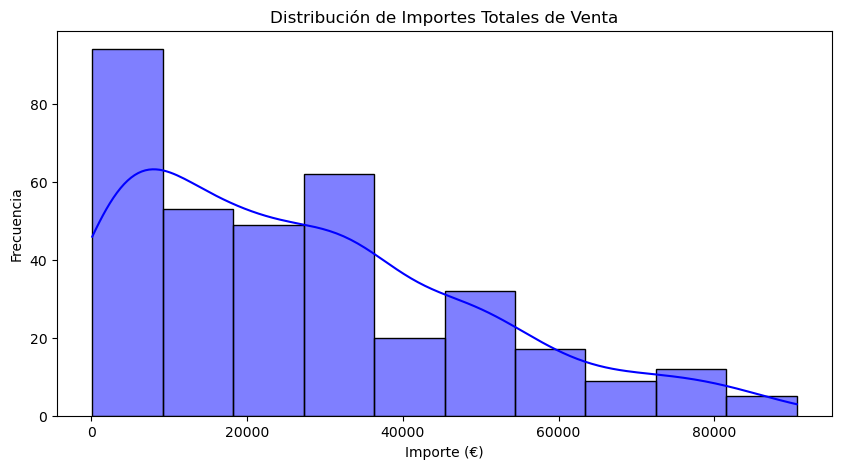

CONCLUSIÓN 1: La mayoría de las ventas se concentran en importes bajos/medios...


In [9]:
# --- GRÁFICO 1: Distribución de Ventas Totales (Histograma) ---
plt.figure(figsize=(10, 5))
sns.histplot(df_completo['Total'], kde=True, color='blue')
plt.title('Distribución de Importes Totales de Venta')
plt.xlabel('Importe (€)')
plt.ylabel('Frecuencia')
plt.show()
print("CONCLUSIÓN 1: La mayoría de las ventas se concentran en importes bajos/medios...")



# GRÁFICA 2

/tmp/ipykernel_5168/976631033.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_completo, x='Linea_negocio', palette='viridis')


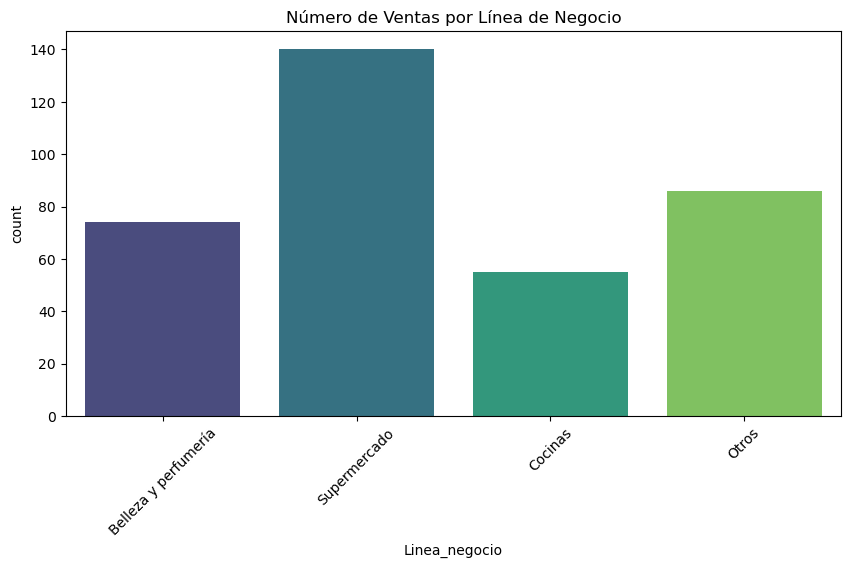

CONCLUSIÓN 2: Se observa qué sector tiene mayor volumen...


In [10]:
# --- GRÁFICO 2: Ventas por Línea de Negocio (Barras) ---
plt.figure(figsize=(10, 5))
sns.countplot(data=df_completo, x='Linea_negocio', palette='viridis') 
plt.title('Número de Ventas por Línea de Negocio')
plt.xticks(rotation=45)
plt.show()
print("CONCLUSIÓN 2: Se observa qué sector tiene mayor volumen...")

# GRÁFICA 3

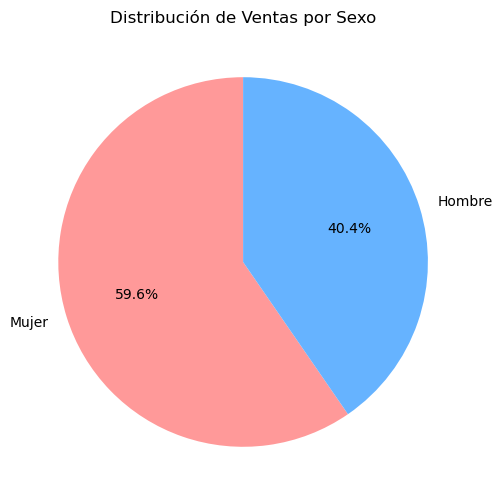

CONCLUSIÓN 3: Muestra si existe un desequilibrio demográfico...


In [11]:
# --- GRÁFICO 3: Proporción por Sexo (Pastel) ---
plt.figure(figsize=(6, 6))
df_completo['Sexo'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title('Distribución de Ventas por Sexo')
plt.ylabel('')
plt.show()
print("CONCLUSIÓN 3: Muestra si existe un desequilibrio demográfico...")

# GRÁFICA 4

ValueError: cannot reindex on an axis with duplicate labels

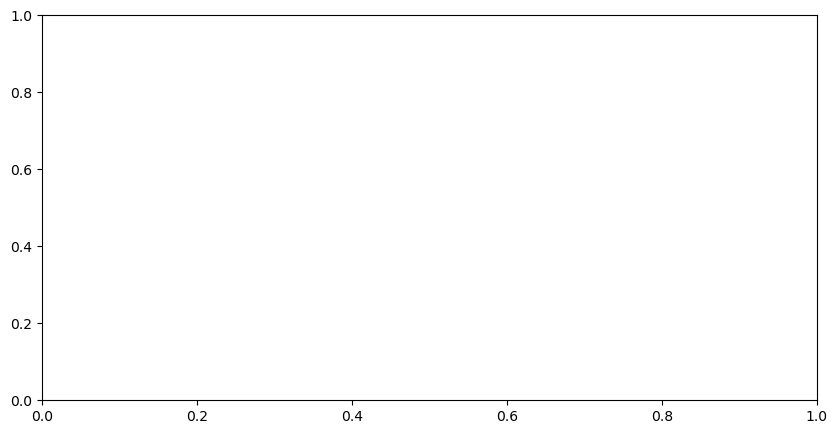

In [13]:

# --- GRÁFICO 4: Relación Cantidad vs Total (Scatter Plot) ---
# CORRECCIÓN: 'Tipo_cliente' (con guion bajo)
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_completo, x='Cantidad', y='Total', hue='Tipo_cliente')
plt.title('Relación entre Cantidad de Productos y Total de Venta')
plt.show()
print("CONCLUSIÓN 4: Existe una correlación lineal positiva clara...")

# GRÁFICA 5

ValueError: cannot reindex on an axis with duplicate labels

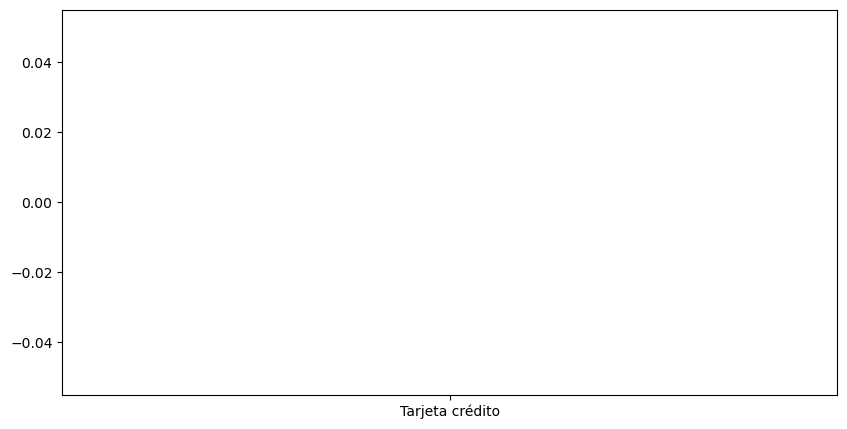

In [14]:


# --- GRÁFICO 5: Total Gastado por Tipo de Pago (Boxplot) ---
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_completo, x='Pago', y='Total')
plt.title('Distribución del Gasto según Método de Pago')
plt.show()
print("CONCLUSIÓN 5: Permite ver si ciertos métodos de pago...")